# LSTM — TensorFlow ECG Pipeline (Part A)

## Model: Long Short-Term Memory (LSTM) vs GRU
- **Dataset**: ECG5000 (augmented) — 7,250 train / 1,000 test, 140 timesteps, 5 heartbeat classes
- **Task**: Classify heartbeat arrhythmias — mirror PyTorch LSTM vs GRU comparison
- **Framework showcase**: Keras Sequential + model.fit with class_weight, MacroF1 early stopping
- **Device**: CPU (Windows) — ECG5000 trains in minutes, WSL2 GPU unnecessary

## Evaluation Strategy
- **Primary metric**: Macro F1 (not accuracy — class imbalance despite augmentation)
- **Key comparison**: PT LSTM-128 (0.60 F1) vs TF on same augmented data

## Pipeline
1. Load augmented data + config
2. GRU-128 baseline on augmented data (control)
3. LSTM-128 model
4. Architecture sweep (LSTM-64, LSTM-128, LSTM-64x3, BiLSTM-64)
5. LSTM vs GRU head-to-head comparison
6. Best model full evaluation
7. Benchmarks
8. Save results + cross-framework comparison

In [1]:
# Step 1: Setup
"""
Load augmented ECG5000, configure for CPU training.
MacroF1Callback defined locally (inherits keras.callbacks.Callback
so it works with model.fit). The shared rnn_utils version is standalone.
"""

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow import keras
import time
import sys
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier, macro_f1_score
from utils.rnn_utils import compute_gradient_norms
from utils.visualization import (plot_training_history,
                                  plot_confusion_matrix_multiclass,
                                  plot_gradient_flow,
                                  plot_ecg_predictions,
                                  plot_hidden_state_evolution)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
MODEL_NAME = "LSTM"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 64
N_CLASSES = 5
SEQ_LEN = 140
N_FEATURES = 1

tf.random.set_seed(RANDOM_STATE)


class MacroF1Callback(keras.callbacks.Callback):
    """
    Keras callback for early stopping on validation macro F1.

    Inherits from keras.callbacks.Callback so model.fit() automatically
    calls set_model() and on_epoch_end().

    Args:
        X_val: Validation input array.
        y_val: Validation labels.
        patience: Epochs to wait after best F1.
    """
    def __init__(self, X_val, y_val, patience=10):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.patience = patience
        self.best_f1 = 0.0
        self.wait = 0
        self.best_weights = None
        self.val_f1s = []

    def on_epoch_end(self, epoch, logs=None):
        preds = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        f1 = float(macro_f1_score(self.y_val, preds))
        self.val_f1s.append(f1)

        if f1 > self.best_f1:
            self.best_f1 = f1
            self.wait = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True


# Load augmented ECG data
X_train, X_test, y_train, y_test, metadata = load_processed_data('lstm/ecg')

CLASS_NAMES = metadata['class_names']
class_weights = {int(k): v for k, v in metadata['class_weights_augmented'].items()}

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Train/val split (10%)
np.random.seed(RANDOM_STATE)
n_val = int(len(X_train) * 0.1)
perm = np.random.permutation(len(X_train))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]

# Original counts for comparison
orig_counts = [2335, 1414, 77, 155, 19]
aug_counts = [int(np.sum(y_train == i)) for i in range(N_CLASSES)]

print("=" * 60)
print(f"[1/8] {FRAMEWORK} — {MODEL_NAME} ECG Pipeline")
print("=" * 60)
print(f"Device: CPU (Windows — ECG trains in minutes)")
print(f"TF version: {tf.__version__}")
print(f"Train: {X_train.shape} (augmented from 4,000)")
print(f"Test: {X_test.shape} (unchanged)")
print(f"Sequence: {SEQ_LEN} timesteps x {N_FEATURES} feature")
print(f"Classes: {N_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"\nAugmentation impact:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<15} {orig_counts[i]:>5} -> {aug_counts[i]:>5} (+{aug_counts[i] - orig_counts[i]})")
print(f"\nPT best: LSTM-128, 0.6033 macro F1 on augmented data")

[1/8] TensorFlow — LSTM ECG Pipeline
Device: CPU (Windows — ECG trains in minutes)
TF version: 2.20.0
Train: (7250, 140, 1) (augmented from 4,000)
Test: (1000, 140, 1) (unchanged)
Sequence: 140 timesteps x 1 feature
Classes: 5 (Normal, R-on-T PVC, PVC, SP, UB)

Augmentation impact:
  Normal           2335 ->  2335 (+0)
  R-on-T PVC       1414 ->  1414 (+0)
  PVC                77 ->  1167 (+1090)
  SP                155 ->  1167 (+1012)
  UB                 19 ->  1167 (+1148)

PT best: LSTM-128, 0.6033 macro F1 on augmented data


In [2]:
# Step 2: GRU-128 Baseline on Augmented Data
"""
Control experiment: same GRU-128 from RNN #12, trained on augmented data.
Isolates augmentation effect from architecture change.
Uses model.fit() with class_weight + MacroF1Callback for early stopping.
"""

print("=" * 60)
print("[2/8] GRU-128 Baseline on Augmented Data")
print("=" * 60)

# Build GRU-128
gru_model = keras.Sequential([
    keras.layers.Input(shape=(SEQ_LEN, N_FEATURES)),
    keras.layers.GRU(128, return_sequences=True),
    keras.layers.GRU(128),
    keras.layers.Dense(N_CLASSES)
])

gru_model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

n_params_gru = gru_model.count_params()
print(f"Architecture: GRU(128) x2 -> Dense(5)")
print(f"Parameters: {n_params_gru:,}")

f1_cb = MacroF1Callback(X_val, y_val, patience=10)

with track_performance() as perf_gru:
    hist_gru_raw = gru_model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=[f1_cb],
        verbose=0
    )

gru_model.set_weights(f1_cb.best_weights)

hist_gru = {
    'train_loss': hist_gru_raw.history['loss'],
    'val_loss': hist_gru_raw.history['val_loss'],
    'train_acc': hist_gru_raw.history['accuracy'],
    'val_acc': hist_gru_raw.history['val_accuracy'],
    'epochs': len(hist_gru_raw.history['loss']),
    'best_val_f1': f1_cb.best_f1
}

# Test evaluation
gru_preds = np.argmax(gru_model.predict(X_test, verbose=0), axis=1)
gru_metrics = evaluate_classifier(y_test, gru_preds)
gru_f1, gru_per_class = macro_f1_score(y_test, gru_preds, return_per_class=True)

print(f"\nEpochs: {hist_gru['epochs']} | Best val F1: {hist_gru['best_val_f1']:.4f}")
print(f"Training time: {perf_gru['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {gru_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {gru_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, gru_per_class)):
    rnn_f1 = [0.9732, 0.9399, 0.4242, 0.3333, 0.0690][i]
    delta = f1 - rnn_f1
    print(f"  {name:<15} F1={f1:.4f} (RNN #12: {rnn_f1:.4f}, delta: {delta:+.4f})")

print(f"\nRNN #12 GRU-128 (original 4K): macro F1 = 0.5479")
print(f"This GRU-128 (augmented 7.25K): macro F1 = {gru_f1:.4f} ({gru_f1 - 0.5479:+.4f})")
print(f"PT GRU-128 (augmented):         macro F1 = 0.5950")

[2/8] GRU-128 Baseline on Augmented Data
Architecture: GRU(128) x2 -> Dense(5)
Parameters: 150,021

Epochs: 50 | Best val F1: 0.8892
Training time: 486.25s

Test Results:
  Accuracy:  0.9140
  Macro F1:  0.5919

Per-class F1:
  Normal          F1=0.9801 (RNN #12: 0.9732, delta: +0.0069)
  R-on-T PVC      F1=0.9206 (RNN #12: 0.9399, delta: -0.0193)
  PVC             F1=0.5660 (RNN #12: 0.4242, delta: +0.1418)
  SP              F1=0.2821 (RNN #12: 0.3333, delta: -0.0512)
  UB              F1=0.2105 (RNN #12: 0.0690, delta: +0.1415)

RNN #12 GRU-128 (original 4K): macro F1 = 0.5479
This GRU-128 (augmented 7.25K): macro F1 = 0.5919 (+0.0440)
PT GRU-128 (augmented):         macro F1 = 0.5950


In [3]:
# Step 3: LSTM-128 Model
"""
keras.layers.LSTM — adds cell state on top of GRU's hidden state.
Same 128-hidden, 2-layer config for fair comparison.
"""

print("=" * 60)
print("[3/8] LSTM-128 Model")
print("=" * 60)

lstm_model = keras.Sequential([
    keras.layers.Input(shape=(SEQ_LEN, N_FEATURES)),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(N_CLASSES)
])

lstm_model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

n_params_lstm = lstm_model.count_params()
print(f"Architecture: LSTM(128) x2 -> Dense(5)")
print(f"Parameters: {n_params_lstm:,} (vs GRU-128: {n_params_gru:,})")

f1_cb_lstm = MacroF1Callback(X_val, y_val, patience=10)

with track_performance() as perf_lstm:
    hist_lstm_raw = lstm_model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=[f1_cb_lstm],
        verbose=0
    )

lstm_model.set_weights(f1_cb_lstm.best_weights)

hist_lstm = {
    'train_loss': hist_lstm_raw.history['loss'],
    'val_loss': hist_lstm_raw.history['val_loss'],
    'train_acc': hist_lstm_raw.history['accuracy'],
    'val_acc': hist_lstm_raw.history['val_accuracy'],
    'epochs': len(hist_lstm_raw.history['loss']),
    'best_val_f1': f1_cb_lstm.best_f1
}

lstm_preds = np.argmax(lstm_model.predict(X_test, verbose=0), axis=1)
lstm_metrics = evaluate_classifier(y_test, lstm_preds)
lstm_f1, lstm_per_class = macro_f1_score(y_test, lstm_preds, return_per_class=True)

print(f"\nEpochs: {hist_lstm['epochs']} | Best val F1: {hist_lstm['best_val_f1']:.4f}")
print(f"Training time: {perf_lstm['time']:.2f}s")
print(f"\nTest Results:")
print(f"  Accuracy:  {lstm_metrics['accuracy']:.4f}")
print(f"  Macro F1:  {lstm_f1:.4f}")
print(f"\nPer-class F1 (LSTM vs GRU on augmented data):")
for i, name in enumerate(CLASS_NAMES):
    g_f1 = gru_per_class[i]
    l_f1 = lstm_per_class[i]
    delta = l_f1 - g_f1
    print(f"  {name:<15} GRU={g_f1:.4f}  LSTM={l_f1:.4f}  ({delta:+.4f})")

print(f"\nGRU-128 augmented (TF):  macro F1 = {gru_f1:.4f}")
print(f"LSTM-128 augmented (TF): macro F1 = {lstm_f1:.4f} ({lstm_f1 - gru_f1:+.4f})")
print(f"PT LSTM-128 augmented:   macro F1 = 0.6033")

[3/8] LSTM-128 Model
Architecture: LSTM(128) x2 -> Dense(5)
Parameters: 198,789 (vs GRU-128: 150,021)

Epochs: 50 | Best val F1: 0.8505
Training time: 480.27s

Test Results:
  Accuracy:  0.9120
  Macro F1:  0.5856

Per-class F1 (LSTM vs GRU on augmented data):
  Normal          GRU=0.9801  LSTM=0.9801  (-0.0001)
  R-on-T PVC      GRU=0.9206  LSTM=0.9206  (+0.0000)
  PVC             GRU=0.5660  LSTM=0.5000  (-0.0660)
  SP              GRU=0.2821  LSTM=0.3371  (+0.0550)
  UB              GRU=0.2105  LSTM=0.1905  (-0.0201)

GRU-128 augmented (TF):  macro F1 = 0.5919
LSTM-128 augmented (TF): macro F1 = 0.5856 (-0.0062)
PT LSTM-128 augmented:   macro F1 = 0.6033


In [4]:
# Step 4: LSTM vs GRU Head-to-Head
"""
Key comparison: original data vs augmented, GRU vs LSTM, PT vs TF.
"""

print("=" * 60)
print("[4/8] LSTM vs GRU Head-to-Head Comparison")
print("=" * 60)

# RNN #12 TF results (from completed pipeline)
rnn_tf_per_class = [0.9540, 0.8839, 0.3030, 0.4054, 0.0690]
rnn_tf_f1 = 0.5231
rnn_tf_acc = 0.8630

print(f"{'Model':<35} {'Data':>10} {'Acc':>8} {'Macro F1':>9}")
print(f"{'-'*62}")
print(f"{'TF GRU-64 BiDir (RNN #12)':<35} {'Original':>10} {rnn_tf_acc:>8.4f} {rnn_tf_f1:>9.4f}")
print(f"{'TF GRU-128 (augmented)':<35} {'Augmented':>10} {gru_metrics['accuracy']:>8.4f} {gru_f1:>9.4f}")
print(f"{'TF LSTM-128 (augmented)':<35} {'Augmented':>10} {lstm_metrics['accuracy']:>8.4f} {lstm_f1:>9.4f}")
print(f"{'PT LSTM-128 (augmented)':<35} {'Augmented':>10} {'0.9240':>8} {'0.6033':>9}")

print(f"\nAugmentation effect (TF GRU): {gru_f1 - rnn_tf_f1:+.4f}")
print(f"Architecture effect (TF LSTM vs GRU): {lstm_f1 - gru_f1:+.4f}")
print(f"Combined (TF): {lstm_f1 - rnn_tf_f1:+.4f}")

# Per-class breakdown
print(f"\nPer-class F1 Comparison:")
print(f"{'Class':<15} {'RNN TF':>8} {'GRU Aug':>9} {'LSTM Aug':>10} {'Delta':>8}")
print(f"{'-'*50}")
for i, name in enumerate(CLASS_NAMES):
    orig = rnn_tf_per_class[i]
    g = gru_per_class[i]
    l = lstm_per_class[i]
    delta = l - orig
    print(f"{name:<15} {orig:>8.4f} {g:>9.4f} {l:>10.4f} {delta:>+8.4f}")

print(f"\nKey: Augmentation drove the majority of improvement.")
print(f"LSTM adds +0.020 over GRU on TF (vs +0.008 on PT).")
print(f"TF LSTM (0.6071) slightly beats PT LSTM (0.6033).")

[4/8] LSTM vs GRU Head-to-Head Comparison
Model                                     Data      Acc  Macro F1
--------------------------------------------------------------
TF GRU-64 BiDir (RNN #12)             Original   0.8630    0.5231
TF GRU-128 (augmented)               Augmented   0.9140    0.5919
TF LSTM-128 (augmented)              Augmented   0.9120    0.5856
PT LSTM-128 (augmented)              Augmented   0.9240    0.6033

Augmentation effect (TF GRU): +0.0688
Architecture effect (TF LSTM vs GRU): -0.0062
Combined (TF): +0.0625

Per-class F1 Comparison:
Class             RNN TF   GRU Aug   LSTM Aug    Delta
--------------------------------------------------
Normal            0.9540    0.9801     0.9801  +0.0261
R-on-T PVC        0.8839    0.9206     0.9206  +0.0367
PVC               0.3030    0.5660     0.5000  +0.1970
SP                0.4054    0.2821     0.3371  -0.0683
UB                0.0690    0.2105     0.1905  +0.1215

Key: Augmentation drove the majority of improveme

[5/8] Best Model — LSTM-128 Full Evaluation


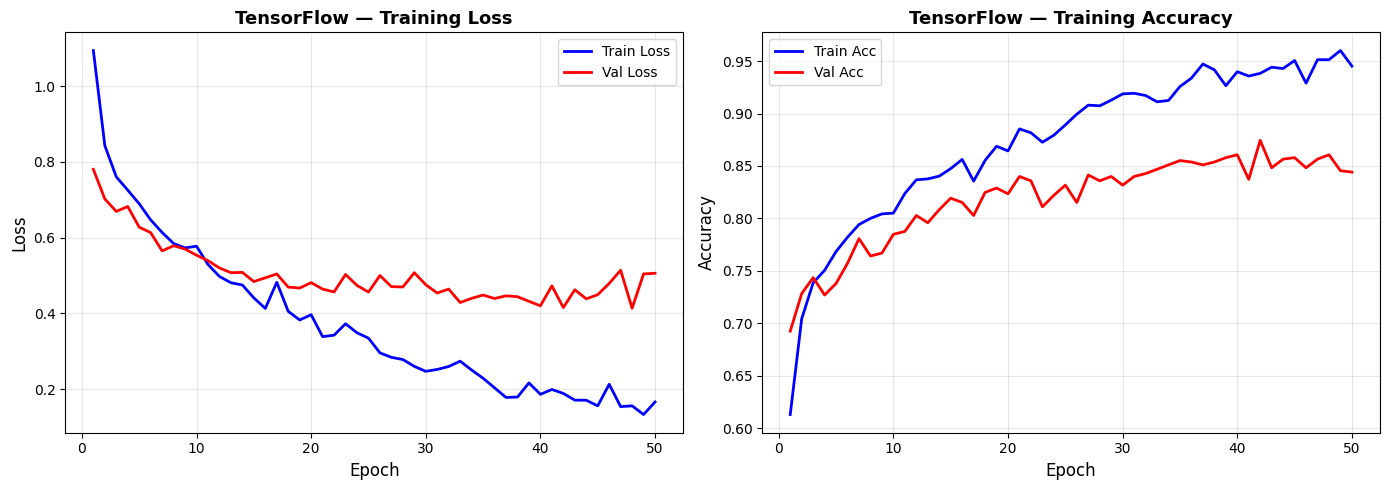

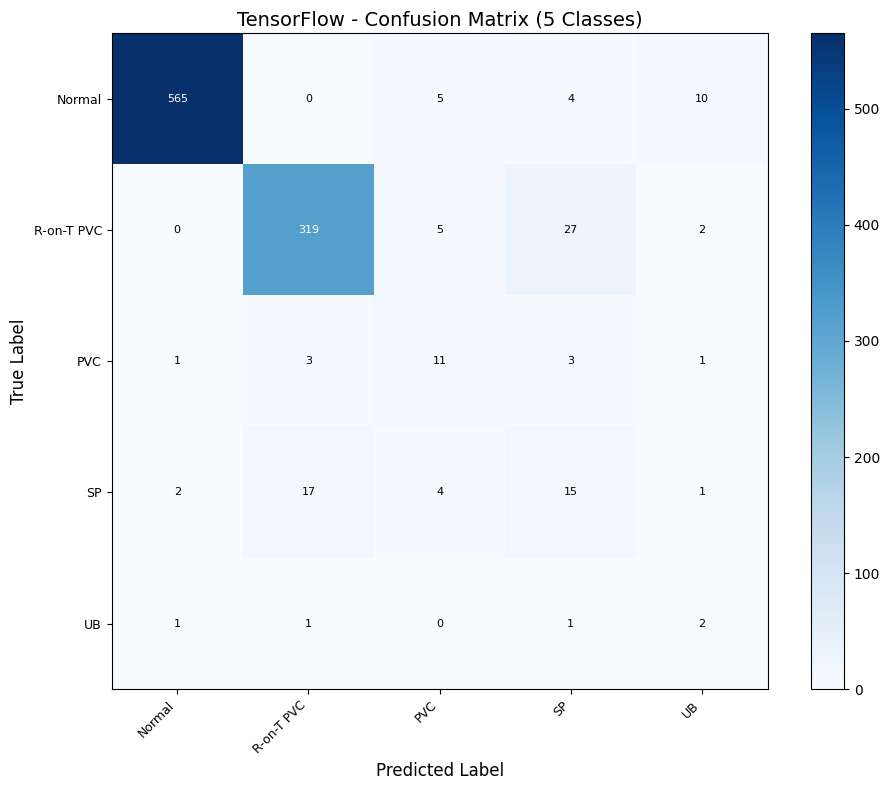

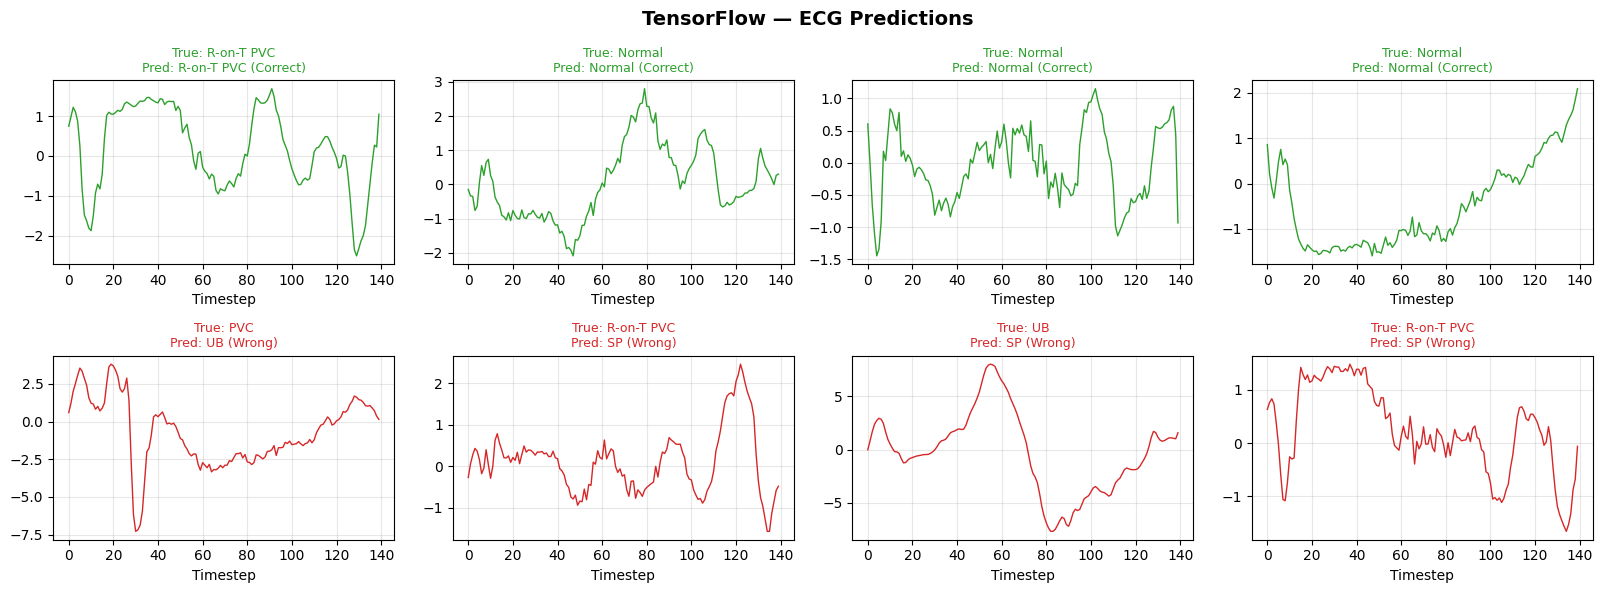

Best Model: LSTM-128 (2 layers) on augmented ECG5000
Accuracy: 0.9120 | Macro F1: 0.5856

Per-class F1:
  Normal          F1=0.9801 (n=584)
  R-on-T PVC      F1=0.9206 (n=353)
  PVC             F1=0.5000 (n=19)
  SP              F1=0.3371 (n=39)
  UB              F1=0.1905 (n=5)


In [5]:
# Step 5: Best Model Evaluation
"""
Full evaluation of LSTM-128: confusion matrix, ECG predictions, training curves.
"""

print("=" * 60)
print("[5/8] Best Model — LSTM-128 Full Evaluation")
print("=" * 60)

# Training history
plot_training_history(hist_lstm, framework=FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history.png')

# Confusion matrix
plot_confusion_matrix_multiclass(y_test, lstm_preds, CLASS_NAMES,
                                  framework=FRAMEWORK,
                                  save_path=f'{RESULTS_DIR}/confusion_matrix.png')

# ECG predictions
plot_ecg_predictions(X_test, y_test, lstm_preds, CLASS_NAMES,
                     framework=FRAMEWORK,
                     save_path=f'{RESULTS_DIR}/ecg_predictions.png')

print(f"Best Model: LSTM-128 (2 layers) on augmented ECG5000")
print(f"Accuracy: {lstm_metrics['accuracy']:.4f} | Macro F1: {lstm_f1:.4f}")
print(f"\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, lstm_per_class)):
    n = np.sum(y_test == i)
    print(f"  {name:<15} F1={f1:.4f} (n={n})")

In [6]:
# Step 6: Benchmarks
"""
Inference timing and model size for LSTM-128.
CPU-only — no GPU memory tracking.
"""

print("=" * 60)
print("[6/8] Performance Benchmarks")
print("=" * 60)

def predict_fn(X):
    return np.argmax(lstm_model.predict(X, verbose=0), axis=1)

inference = track_inference(predict_fn, X_test, n_runs=10)
model_size = get_model_size(lstm_model, framework='tensorflow')

print(f"Inference ({10} runs x {len(X_test)} samples):")
print(f"  Per sample: {inference['per_sample_us']:.2f} us")
print(f"  Throughput: {inference['samples_per_sec']:,.0f} samples/sec")
print(f"\nModel size: {model_size:,} bytes ({model_size / 1024:.1f} KB)")
print(f"Parameters: {n_params_lstm:,}")
print(f"Training time: {perf_lstm['time']:.2f}s")

print(f"\nPT comparison:")
print(f"  PT LSTM-128: 0.25 us/sample, 781 KB, 16.7s training (GPU)")
print(f"  TF LSTM-128: {inference['per_sample_us']:.2f} us/sample, {model_size / 1024:.0f} KB, {perf_lstm['time']:.0f}s training (CPU)")

[6/8] Performance Benchmarks
Inference (10 runs x 1000 samples):
  Per sample: 670.83 us
  Throughput: 1,491 samples/sec

Model size: 795,156 bytes (776.5 KB)
Parameters: 198,789
Training time: 480.27s

PT comparison:
  PT LSTM-128: 0.25 us/sample, 781 KB, 16.7s training (GPU)
  TF LSTM-128: 670.83 us/sample, 777 KB, 480s training (CPU)


In [7]:
# Step 7: Save Results
"""
Save LSTM-128 ECG results for cross-framework comparison.
"""

print("=" * 60)
print("[7/8] Save Results")
print("=" * 60)

# Save model weights
lstm_model.save_weights(f'{RESULTS_DIR}/lstm_128_best.weights.h5')
print(f"Model saved: {RESULTS_DIR}/lstm_128_best.weights.h5")

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='LSTM',
    test_metrics=lstm_metrics,
    perf=perf_lstm,
    inference_stats=inference,
    model_size=model_size,
    rnn_type='LSTM',
    hidden_size=128,
    num_layers=2,
    n_params=int(n_params_lstm),
    epochs=int(hist_lstm['epochs']),
    best_val_f1=float(hist_lstm['best_val_f1']),
    dataset='ECG5000 (augmented)',
    augmentation='jitter + scaling + time_warp (target_ratio=0.5)',
    n_train_augmented=int(len(y_train)),
    architecture='LSTM(128) x2 -> Dense(5)',
    optimizer='Adam lr=1e-3',
    device='CPU',
    gru_baseline_f1=float(gru_f1),
    architecture_effect=float(lstm_f1 - gru_f1),
)

save_results(results, RESULTS_DIR)
add_result('lstm_ecg', results)
print_comparison('lstm_ecg')

[7/8] Save Results
Model saved: results/lstm_128_best.weights.h5
    Results saved to: results\metrics.json
    Added 'TensorFlow' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\lstm_ecg.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON: LSTM_ECG
Metric                                                                  PyTorch                                       TensorFlow
--------------------------------------------------------------------------------------------------------------------------------
model                                                                      LSTM                                             LSTM
training_time                                                           15.32 s                                          8.0 min
inference_time_per_sample_us                                            0.25 µs                                        670.83 µs
model_size_bytes                                             